In [1]:
!uv pip install -q --system numba-cuda==0.4.0

In [2]:
import numba.cuda as cuda
from numba import config
config.CUDA_ENABLE_PYNVJITLINK = 1
import matplotlib.pyplot as plt
import numpy as np
import time

Original

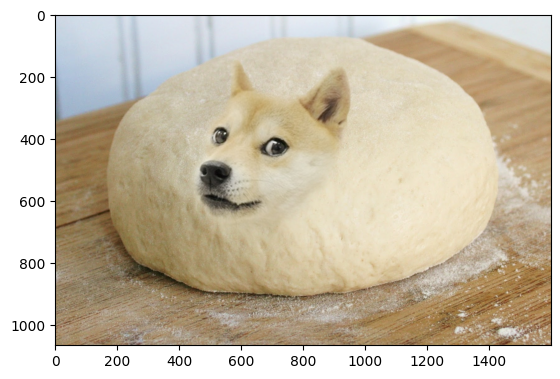

In [3]:
img_path = "/content/Doge.jpg"
img = plt.imread(img_path)
plt.imshow(img)

Flatten

In [4]:
height, width, channels = img.shape
pixel_count = height * width
print(f"Image shape: {img.shape}, Total pixels: {pixel_count}")
img_1D = img.reshape(pixel_count, 3).astype(np.uint8)
print(f"Image shape after flatten: {img_1D.shape}")

Image shape: (1065, 1600, 3), Total pixels: 1704000
Image shape after flatten: (1704000, 3)


Grayscale CPU

CPU time: 12.7815 seconds


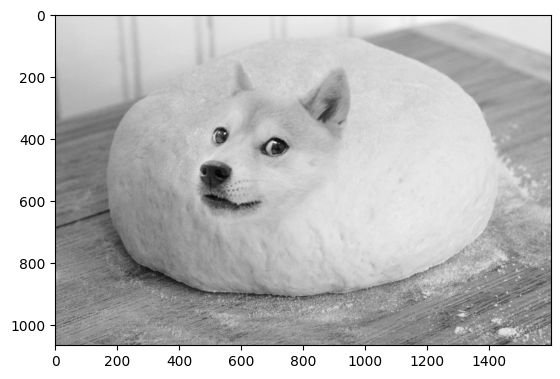

In [5]:
def grayscale_cpu(rgb_array):
    gray = np.zeros(pixel_count, dtype=np.uint8)
    for i in range(pixel_count):
        r, g, b = rgb_array[i]
        gray[i] = 0.2989 * r + 0.5870 * g + 0.1140 * b
    return gray

start = time.time()
gray_cpu = grayscale_cpu(img_1D)
cpu_time = time.time() - start
print(f"CPU time: {cpu_time:.4f} seconds")
gray_cpu_image = gray_cpu.reshape(height, width)
plt.imshow(gray_cpu_image, cmap='gray')


GrayScale GPU

GPU time: 0.8667 seconds


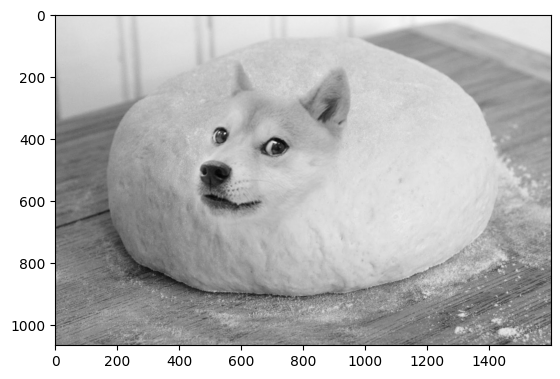

In [6]:
@cuda.jit
def grayscale_gpu(src, dst):
# where are we in the input?
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  g = np.uint8((src[tidx, 0] + src[tidx, 1] + src[tidx, 2]) / 3)
  dst[tidx, 0] = dst[tidx, 1] = dst[tidx, 2] = g

d_src = cuda.to_device(img_1D)
d_dst = cuda.device_array((pixel_count, 3), dtype=np.uint8)
block_size = 256
grid_size = (pixel_count + (block_size - 1)) // block_size

start = time.time()
grayscale_gpu[grid_size, block_size](d_src, d_dst)
cuda.synchronize()
gpu_time = time.time() - start
print(f"GPU time: {gpu_time:.4f} seconds")

gray_gpu = d_dst.copy_to_host()
gray_gpu_image = gray_gpu[:, 0].reshape(height, width)
plt.imshow(gray_gpu_image, cmap='gray')

Try different block size

Block size 32: 0.0007 seconds
Block size 64: 0.0006 seconds
Block size 128: 0.0006 seconds
Block size 256: 0.0005 seconds
Block size 512: 0.0006 seconds
Block size 1024: 0.0006 seconds


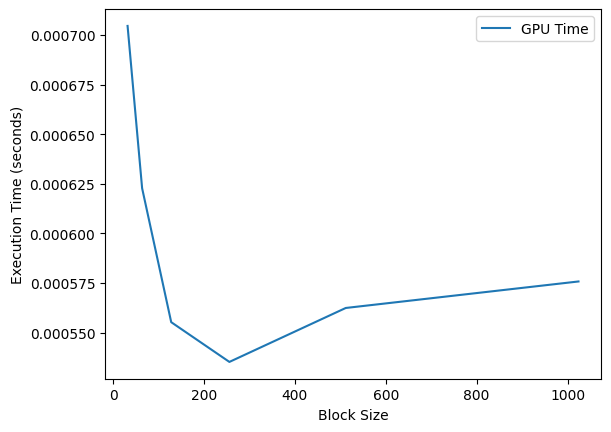

In [7]:
block_sizes = [32, 64, 128, 256, 512, 1024]
gpu_times = []

# Prepare GPU data
d_src = cuda.to_device(img_1D)
d_dst = cuda.device_array((pixel_count, 3), dtype=np.uint8)

# Measure GPU execution time for each block size
for block_size in block_sizes:
    grid_size = (pixel_count + (block_size - 1)) // block_size
    start_time = time.time()
    grayscale_gpu[grid_size, block_size](d_src, d_dst)
    cuda.synchronize()
    gpu_time = time.time() - start_time
    gpu_times.append(gpu_time)
    print(f"Block size {block_size }: {gpu_time:.4f} seconds")

plt.plot(block_sizes, gpu_times, label='GPU Time')
plt.xlabel('Block Size')
plt.ylabel('Execution Time (seconds)')
plt.legend()